# Florida barrier-construction event study — Callaway–Sant'Anna DiD (Stata)

**Source.** `data/florida/panel/assembled/event_study_panel.parquet`, built
by `python -m src.cli florida data panel assemble`
(`src/regions/florida/sources/panel/assemble.py`). For a general
descriptive tour of the *whole* panel (grain, outcome coverage, all four
treatment tiers, every covariate cluster's match rate), see
[`descriptive_statistics.ipynb`](descriptive_statistics.ipynb) (Python).
This notebook is scoped narrower and deeper: it collapses the panel to one
row per school-year, describes it, then actually estimates a Callaway &
Sant'Anna (2021) staggered-adoption event study and a covariate-augmented
ATT table — using real Stata (`csdid`/`drdid`, Rios-Avila, Sant'Anna &
Callaway) called from Python via StataCorp's own
[`pystata`](https://www.stata.com/python/pystata/) integration, not a
Python reimplementation. It mirrors
[`sweden/analysis.ipynb`](../sweden/analysis.ipynb) one-for-one in
structure; only the outcome-collapsing step and the treatment/covariate
column names differ, since Florida's panel is wide (one row per
`msid x grade x subject x year`) rather than Sweden's long grain.

**Outcome**: `z_mss_w` — the school mean scale score, standardised within
grade/subject/year/regime (`docs/data/florida/covariates.md` recommends
weighting by test-takers and restricting to regular schools). Since the
panel has one row per grade/subject, not per school-year, §1 collapses to
one `z_mss_w` value per `(msid, year)` via an `n_students`-weighted average
across whichever grade/subject cells that school-year has, after
restricting to `is_regular == True` schools.

**Treatment**: `ever_treated_protected` / `first_treat_year_protected`
(switched 2026-09-24). A school is treated once it lies in an FDOT wall's
**protected area**:
- on the wall's side of its road
- within 600m of it
- with its nearest point on that road beside the wall's own stretch (±50m)

FDOT draws each wall where it stands, so the side comes straight from the
wall's geometry: 1,262 of 1,263 walls, agreeing with FDOT's own
`BLOC_SIDE` label for 98.3%. See
[`docs/data/florida/barrier_protection.md`](../../../docs/data/florida/barrier_protection.md).

The previous `same_side` tier compared signs from different road segments
for two-thirds of school–wall pairs, and counted schools far along the road
past the wall; the Summary's dated notes record that run. Florida has one
barrier network, no road/rail split.

**Honesty note, not hidden**: read the standard errors, not just the point
estimates. Covariate coverage varies a lot by cluster: traffic ~71%,
road-project and shock flags 100%, `staff_avg_teacher_salary` only ~5%, so
salary is excluded below. `timing_unknown` walls are dropped from the
treated group rather than silently miscoded as controls, same discipline
as the Sweden notebook.

## 1. Build the CS-ready analysis dataset (Python)


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import np, pd

from src.regions.florida.sources.panel.shared import assembled_panel_path

panel = pd.read_parquet(assembled_panel_path())
print(f"{len(panel):,} panel rows loaded, {panel['msid'].nunique():,} distinct schools, "
      f"grain msid x grade x subject x year")


660,681 panel rows loaded, 5,039 distinct schools, grain msid x grade x subject x year


In [2]:
MATCH_TIER = "protected"  # switched 2026-09-24: the school lies in a wall's protected area -- same side AND beside the wall's own stretch (docs/data/florida/barrier_protection.md)

# Restrict to regular schools with a real weighted score, per
# docs/data/florida/covariates.md's "weight by test-takers; restrict to
# regular schools with stable grade spans" guidance.
rows = panel.loc[(panel["is_regular"] == True) & panel["z_mss_w"].notna() & panel["n_students"].notna()].copy()
print(f"{len(rows):,} of {len(panel):,} panel rows kept (is_regular & real z_mss_w & n_students)")

# Collapse grade/subject cells to one z_mss_w per (msid, year), weighted by
# test-takers (n_students) -- the panel's other columns (treatment,
# covariates) are already constant within (msid, year), confirmed directly.
def _wavg(g):
    return float(np.average(g["z_mss_w"], weights=g["n_students"]))

outcome_vals = (
    rows.groupby(["msid", "year"])
    .apply(_wavg, include_groups=False)
    .rename("z_mss_w_school")
    .reset_index()
)

ever_col, first_col, unknown_col = (
    f"ever_treated_{MATCH_TIER}", f"first_treat_year_{MATCH_TIER}", f"timing_unknown_{MATCH_TIER}",
)
# traffic: the busiest RCI road within 500m of the school (switched 2026-09-24
# from the single nearest arterial, which is the protecting wall's own road
# for only ~52% of protected schools)
covariate_cols = ["traffic_max_aadt_500m", "n_road_projects_active", "shock_any_major_disaster"]
side_unknown_col = f"{MATCH_TIER}_unknown"
other_cols = rows.drop_duplicates(["msid", "year"])[
    ["msid", "year", ever_col, first_col, unknown_col, side_unknown_col, *covariate_cols]
]

merged = outcome_vals.merge(other_cols, on=["msid", "year"], how="left")
print(f"{len(merged):,} school-year rows after collapsing grade/subject")

# A school ever-treated whose matched barrier's construction year is itself
# unknown can't be placed in event time -- drop it rather than silently
# mis-code it as a control (same discipline as the Sweden notebook).
drop_mask = merged[ever_col] & merged[unknown_col]
print(f"dropping {drop_mask.sum():,} rows ({merged.loc[drop_mask, 'msid'].nunique():,} schools): "
      "ever-treated but construction year unknown")
# Likewise a never-treated school beside a wall whose side is unknown may be
# protected, so it is not a clean control either -- drop it too.
unknown_mask = merged[side_unknown_col] & ~merged[ever_col]
print(f"dropping {unknown_mask.sum():,} rows ({merged.loc[unknown_mask, 'msid'].nunique():,} schools): "
      "not treated, but beside a wall whose side is unknown")
merged = merged.loc[~(drop_mask | unknown_mask)].copy()

merged["id"] = merged["msid"].astype("int64")
merged["gvar"] = np.where(merged[ever_col], merged[first_col], 0.0)

analysis = merged[["id", "year", "gvar", "z_mss_w_school", *covariate_cols]].rename(columns={
    "z_mss_w_school": "z_mss_w",
    "n_road_projects_active": "n_road_projects",
    "shock_any_major_disaster": "shock_major",
})
analysis["shock_major"] = analysis["shock_major"].astype("float64")  # Stata-friendly (avoid a bool dtype round-trip)

n_treated_schools = analysis.loc[analysis["gvar"] > 0, "id"].nunique()
print(f"\nfinal analysis dataset: {len(analysis):,} rows, {analysis['id'].nunique():,} schools, "
      f"{n_treated_schools:,} with a usable treatment year")
print("\ncovariate coverage (share non-missing):")
print(analysis[["traffic_max_aadt_500m", "n_road_projects", "shock_major"]].notna().mean())


562,408 of 660,681 panel rows kept (is_regular & real z_mss_w & n_students)


72,616 school-year rows after collapsing grade/subject
dropping 46 rows (2 schools): ever-treated but construction year unknown
dropping 0 rows (0 schools): not treated, but beside a wall whose side is unknown

final analysis dataset: 72,570 rows, 4,066 schools, 102 with a usable treatment year

covariate coverage (share non-missing):
traffic_max_aadt_500m    0.711479
n_road_projects          1.000000
shock_major              1.000000
dtype: float64


In [3]:
# `gvar` is a barrier-construction year, not constrained to fall inside the
# outcome panel's own observed window -- worth checking directly rather
# than assuming every "treated" school actually has both a pre- and a
# post-period observed (same check as sweden/analysis.ipynb §1).
treated_gvar = analysis.loc[analysis["gvar"] > 0].groupby("id")["gvar"].first()
panel_min, panel_max = analysis["year"].min(), analysis["year"].max()

before_panel = int((treated_gvar < panel_min).sum())
after_panel = int((treated_gvar > panel_max).sum())
inside_panel = len(treated_gvar) - before_panel - after_panel

print(f"panel outcome window: {panel_min}-{panel_max}")
print(f"{len(treated_gvar)} schools with a usable treatment year:")
print(f"  construction before {panel_min} (no pre-period ever observed): {before_panel}")
print(f"  construction after {panel_max} (no post-period ever observed):  {after_panel}")
print(f"  construction inside the observed window:                       {inside_panel}")


panel outcome window: 2003-2026
102 schools with a usable treatment year:
  construction before 2003 (no pre-period ever observed): 31
  construction after 2026 (no post-period ever observed):  0
  construction inside the observed window:                       71


`staff_avg_teacher_salary`/`staff_median_teacher_salary` (Cluster B) are
deliberately excluded from the covariate set above: real coverage in this
panel is only ~5%, far too sparse to add as a `csdid` covariate without
gutting the sample. `nbhd_*` (Cluster F, ~68-99% coverage) is a real,
better-populated candidate not used here only to keep this notebook's
three-covariate structure a direct match for `sweden/analysis.ipynb` §5
(traffic, then two more) — swap `n_road_projects`/`shock_major` for
`nbhd_*` columns the same way if you want to try it.


## 2. Hand off to Stata


In [3]:
# StataCorp's own Python integration, shipped inside the Stata install itself
# (not on PyPI) -- adjust this path if Stata is installed somewhere else on
# your machine. Registers the %%stata cell magic used in every cell below.
STATA_UTILITIES = "/Applications/Stata/utilities"
if STATA_UTILITIES not in sys.path:
    sys.path.insert(0, STATA_UTILITIES)

from pystata import config

config.init("mp")  # edition matches this machine's license (StataMP); use "se"/"be" if yours differs



  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      Stata 18.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: Single-user 2-core  perpetual
Serial number: 501806386291
  Licensed to: Universität Basel
               WWZ

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


In [4]:
%%stata -d analysis -force
set processors 1
* csdid's bootstrap step is unstable under multi-core StataMP in some
* sandboxed/virtualized environments (segfaults observed in this repo's own
* CI-style sandbox) -- forcing single-threaded execution is the safe
* default; raise it back to `set processors 2` (or your machine's core
* count) once you've confirmed it's stable in your own environment.
xtset id year



. set processors 1
    The maximum number of processors or cores being used is changed from 2 to
    1.  It can be set to any number between 1 and 2

. * csdid's bootstrap step is unstable under multi-core StataMP in some
. * sandboxed/virtualized environments (segfaults observed in this repo's own
. * CI-style sandbox) -- forcing single-threaded execution is the safe
. * default; raise it back to `set processors 2` (or your machine's core
. * count) once you've confirmed it's stable in your own environment.
. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. 


## 3. Descriptive statistics on the analysis panel


In [5]:
%%stata
describe z_mss_w gvar traffic_max_aadt_500m n_road_projects shock_major
summarize z_mss_w traffic_max_aadt_500m n_road_projects shock_major

* one row per school: is it ever-treated (usable timing), and when
preserve
gen byte ever_treated = gvar > 0
bysort id (year): keep if _n == 1

count
local n_schools = r(N)
count if ever_treated
local n_treated = r(N)
di as text _n "distinct schools: " as result `n_schools'
di as text "ever-treated (usable timing): " as result `n_treated'

summarize gvar if ever_treated
restore



. describe z_mss_w gvar traffic_max_aadt_500m n_road_projects shock_major

Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
z_mss_w         double  %10.0g                
gvar            double  %10.0g                
traffic_ma~500m double  %10.0g                
n_road_projects long    %12.0g                
shock_major     double  %10.0g                

. summarize z_mss_w traffic_max_aadt_500m n_road_projects shock_major

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     z_mss_w |     72,570   -.0585279    .9334351  -5.037154   4.774788
traffic~500m |     51,632    31311.13    37448.18   116.0714   282634.4
n_road_pro~s |     72,570    .2480777    1.935072          0        182


 shock_major |     72,570    .3184512    .4658787          0          1

. 
. * one row per school: is it ever-treated (usable timing), and when
. preserve

. gen byte ever_treated = gvar > 0

. bysort id (year): keep if _n == 1


(68,504 observations deleted)

. 
. count
  4,066

. local n_schools = r(N)

. count if ever_treated
  102

. local n_treated = r(N)

. di as text _n "distinct schools: " as result `n_schools'

distinct schools: 4066

. di as text "ever-treated (usable timing): " as result `n_treated'
ever-treated (usable timing): 102

. 
. summarize gvar if ever_treated

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        gvar |        102    2007.471    9.453069       1991       2024

. restore

. 


In [6]:
%%stata
* covariate balance: treated vs. never-treated schools (row-level, not
* collapsed -- a simple descriptive check, not a formal balance test)
gen byte ever_treated = gvar > 0
tabstat traffic_max_aadt_500m n_road_projects shock_major, by(ever_treated) stat(mean sd n) columns(statistics)
drop ever_treated



. * covariate balance: treated vs. never-treated schools (row-level, not
. * collapsed -- a simple descriptive check, not a formal balance test)
. gen byte ever_treated = gvar > 0

. tabstat traffic_max_aadt_500m n_road_projects shock_major, by(ever_treated) s
> tat(mean sd n) columns(statistics)



Summary for variables: traffic_max_aadt_500m n_road_projects shock_major
Group variable: ever_treated 

ever_treated |      Mean        SD         N
-------------+------------------------------
           0 |  27968.82  31024.86     49808
             |   .232375  1.884074     70610
             |  .3196573  .4663471     70610
-------------+------------------------------
           1 |  122579.6   69137.9      1824
             |  .8137755  3.230709      1960
             |      .275  .4466282      1960
-------------+------------------------------
       Total |  31311.13  37448.18     51632
             |  .2480777  1.935072     72570
             |  .3184512  .4658787     72570
--------------------------------------------



. drop ever_treated

. 


## 4. Callaway–Sant'Anna event study — simple DiD, no controls


In [8]:
%%stata -gw 7 -gh 4.5
quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple



. quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------


         ATT |  -.0505402   .0683346    -0.74   0.460    -.1844736    .0833932
------------------------------------------------------------------------------



. 


`csdid` itself is run with `quietly`: its default display is the *full*
group-time ATT(g,t) array (one block per treatment cohort, every
comparison period) — real output, but a wall of numbers that answers a
different question than "what's the overall effect." `estat simple` above
is the single overall ATT (the Callaway–Sant'Anna analogue of a textbook
2x2 DiD coefficient), aggregating every group-time ATT(g,t) with the
estimator's default weighting. The event-study plot below breaks that same
estimate out by event time instead, which is what actually lets you check
for pre-trends.


Nothing here suggests an effect, or a pre-trend:
- **Overall:** the unconditional ATT is -0.051 SD on `z_mss_w` (SE 0.068,
  p=0.460, 95% CI -0.18 to 0.08).
- **Pre-period:** `Pre_avg` is -0.008 (SE 0.011, p=0.453).
- **Post-period:** `Post_avg` is -0.026 (SE 0.053, p=0.626).
- **Individual periods:** every coefficient `Tm8`–`Tp8` is insignificant at
  10%. The largest in magnitude is `Tp8` (-0.110, p=0.285), at the
  window's edge where the fewest cohorts are observed.

The estimate rests on 102 treated schools, 71 of them built inside the
2003–2026 window (§1). That is fewer than the old `same_side` tier's 182,
but a far larger in-window sample than Sweden's 18, and it is a clean
null.

One technical note on reading `Tm1`-`Tm8`, carried over from the Sweden
notebook: `csdid`'s default ("short gap") pre-treatment ATTs compare each
period `T-1` to `T`, not to the cohort's own `G-1`. They are a
period-by-period placebo test, not a comparison to a single fixed
reference. (`long2` would reanchor every pre-treatment ATT to `G-1`
instead, closer to a textbook event-study normalization; not switched to
here, same open item as Sweden's.)


. estat event, window(-8 8) estore(cs_event)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |  -.0080823   .0107638    -0.75   0.453     -.029179    .0130144
    Post_avg |  -.0257459    .052876    -0.49   0.626     -.129381    .0778893
         Tm8 |  -.0002972   .0597252    -0.00   0.996    -.1173564    .1167619
         Tm7 |   -.053106    .041006    -1.30   0.195    -.1334764    .0272644
         Tm6 |  -.0150577   .0309499    -0.49   0.627    -.0757183     .045603
         Tm5 |   .0071262   .0343416     0.21   0.836     -.060182    .0744345
         Tm4 |  -.0157486   .0346655    -0.45   0.650    -.0836916    .0521945
         Tm3 |   .0447414   .0471752     0.95   0.343    -.0477203    .1372031
         Tm2 |  -.0024402   .0450326    -0.05   0.957    -.0907025     .085822
         Tm1 |  -.0298761   .0324863    -0.92   0.35


. event_plot cs_event, stub_lag(Tp#) stub_lead(Tm#) trimlead(8) trimlag(8) ///
>     together plottype(scatter) ciplottype(rcap) default_look ///
>     graph_opt(xtitle("Event time (years since barrier construction)") ///
>     ytitle("ATT on z_mss_w") ///
>     title("Callaway-Sant'Anna event study: Florida protected-area barrier con
> struction") ///
>     xlabel(-8(2)8) legend(off))



. 


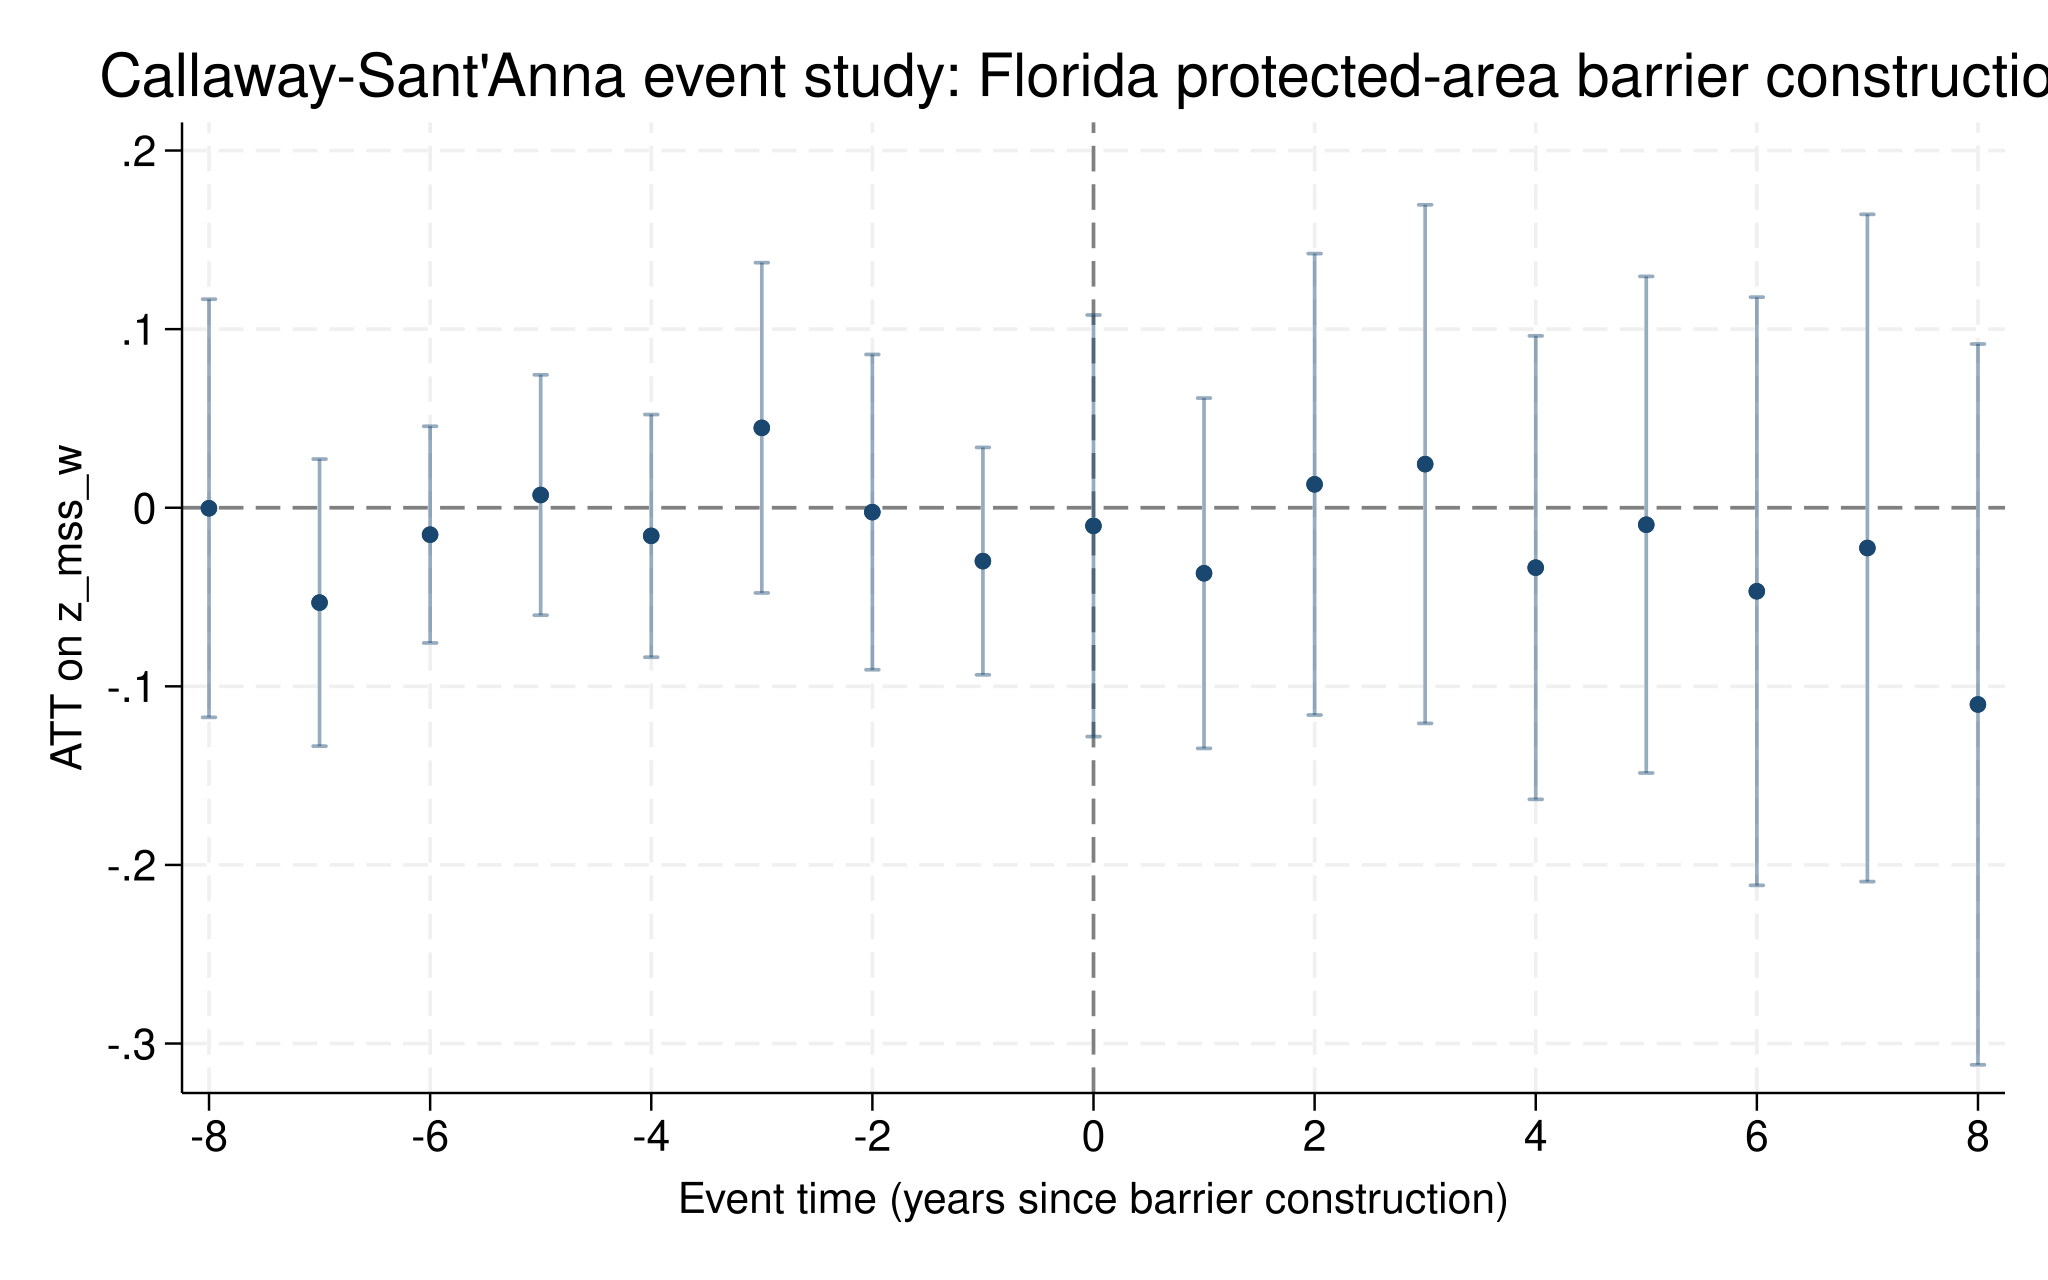

In [9]:
%%stata -gw 8 -gh 5
estat event, window(-8 8) estore(cs_event)
event_plot cs_event, stub_lag(Tp#) stub_lead(Tm#) trimlead(8) trimlag(8) ///
    together plottype(scatter) ciplottype(rcap) default_look ///
    graph_opt(xtitle("Event time (years since barrier construction)") ///
    ytitle("ATT on z_mss_w") ///
    title("Callaway-Sant'Anna event study: Florida protected-area barrier construction") ///
    xlabel(-8(2)8) legend(off))


## 5. Table with increasing controls


Callaway & Sant'Anna's doubly-robust estimator (`method(dripw)`, the
default) takes covariates directly on the `csdid` command line — they enter
both an outcome-regression and a propensity-score model for each (g,t) pair,
not as a single pooled regression coefficient, so there's no single "the
coefficient on X" to report as a table row the way a standard OLS table
would. What *is* comparable across specs is the aggregated overall ATT
(`estat simple`) — the increasing-controls analogue here is re-running the
whole group-time ATT array with a growing covariate set and comparing that
one summary number spec to spec. (`eststo`/`esttab` don't work directly on
`csdid`'s stored estimates — its `e(b)` holds the full internal
group-time weight-parameter array, not just the aggregated ATT — so the
table below is built by hand from `estat simple`'s `r(table)`, the pattern
used in the `csdid` Stata Journal article itself.) A covariate with
missing values drops any (g,t) pair-comparison where it's unobserved for
one of the two periods being compared, which is why `N` shrinks spec to
spec — real attrition, not a bug.


In [7]:
%%stata
matrix results = J(4, 4, .)
matrix colnames results = ATT SE z N

quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[1,1] = b[1,1]
matrix results[1,2] = b[2,1]
matrix results[1,3] = b[3,1]
matrix results[1,4] = e(N)

quietly csdid z_mss_w traffic_max_aadt_500m, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[2,1] = b[1,1]
matrix results[2,2] = b[2,1]
matrix results[2,3] = b[3,1]
matrix results[2,4] = e(N)

quietly csdid z_mss_w traffic_max_aadt_500m n_road_projects, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[3,1] = b[1,1]
matrix results[3,2] = b[2,1]
matrix results[3,3] = b[3,1]
matrix results[3,4] = e(N)

quietly csdid z_mss_w traffic_max_aadt_500m n_road_projects shock_major, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[4,1] = b[1,1]
matrix results[4,2] = b[2,1]
matrix results[4,3] = b[3,1]
matrix results[4,4] = e(N)

matrix rownames results = "No controls" "+ Traffic" "+ Traffic, road projects" "+ Traffic, road projects, shocks"
matrix list results, format(%9.3f)



. matrix results = J(4, 4, .)

. matrix colnames results = ATT SE z N

. 
. quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------


             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0505402   .0683346    -0.74   0.460    -.1844736    .0833932
------------------------------------------------------------------------------


...

Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.1115711   .0752611    -1.48   0.138    -.2590802    .0359379
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix results[4,1] = b[1,1]

. matrix results[4,2] = b[2,1]

. matrix results[4,3] = b[3,1]

. matrix results[4,4] = e(N)

. 
. matrix rownames results = "No controls" "+ Traffic" "+ Traffic, road projects
> " "+ Traffic, road projects, shocks"

. matrix list results, format(%9.3f)



results[4,4]
                    ATT         SE          z          N
 No controls     -0.051      0.068     -0.740  71574.000
   + Traffic     -0.135      0.076     -1.767  50706.000
+ Traffic,~s     -0.131      0.076     -1.721  50706.000
+ Traffic,~s     -0.112      0.075     -1.482  50706.000

. 


The traffic control here is `traffic_max_aadt_500m`, the busiest RCI road
within 500m of the school (switched 2026-09-24). The previous single-nearest-
arterial control missed the shielded road for about half of protected
schools. §3's balance table shows why the choice matters: treated schools
sit by roads averaging 122,580 vehicles/day, against 27,969 for the rest.

Adding controls pushes the ATT *more negative*: -0.051 (no controls) →
-0.135 (+traffic, SE 0.076, p=0.077) → -0.131 (+road projects, p=0.085) →
-0.112 (+shocks, SE 0.075, p=0.138). The first two are borderline at 10%.
Two things to separate:
- **The sample shrinks** when traffic enters: `N` falls 29% (71,574 →
  50,706), the ~71% traffic coverage. `n_road_projects` and `shock_major`
  are fully covered, so they shrink nothing further.
- **The covariate itself:** the check below re-runs the *no-controls* spec
  on exactly the traffic-complete sample.

In [8]:
%%stata
quietly csdid z_mss_w if !missing(traffic_max_aadt_500m), ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple



. quietly csdid z_mss_w if !missing(traffic_max_aadt_500m), ivar(id) time(year)
>  gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0948051   .0737762    -1.29   0.199    -.2394038    .0497936
------------------------------------------------------------------------------



. 


On the traffic-complete sample, the no-controls ATT is already -0.095
(SE 0.074, p=0.199). So most of the move from -0.051 to -0.135 is the
sample: school-years with a traffic match are a different slice of
Florida. Adding traffic itself contributes a further -0.040. Every estimate
in the chain (-0.051 → -0.095 → -0.135 → -0.131 → -0.112) has a 95% CI
containing zero, and the only ones near 10% point *negative*. Nothing here
supports a protective effect on `z_mss_w`. If anything, the estimates lean
slightly negative, in line with §7's `pct_l1` and §8's `frpl_share`
drift.

## 6. Weighting: the score vs. the regression

Florida's panel already carries two different standardisations of the same
underlying test score -- `z_mss` (each `year x subject x grade` cell
standardised against an unweighted school mean/std) and `z_mss_w` (the
same cell standardised against an `n_students`-weighted mean/std,
per `docs/data/florida/README.md`'s definition) -- which is the exact
same **weighting the score** lever `sweden/analysis.ipynb` §6 uses
`meritvärde_z`/`meritvärde_zw` for. **Weighting the regression** is a
separate, non-substitutable lever: `csdid`'s own `[iweight=enrollment]`,
using total school membership (NCES CCD `enrollment`, ~95% coverage in
this panel, *not* the test-taker count `n_students` already used to
collapse grade/subject cells to one row per school-year in §1) -- this
changes which schools drive the estimate, answering "effect per treated
*student*" instead of "effect per treated *school*". The table below runs
all four combinations on the same estimating sample, mirroring Sweden's
§6 exactly.


In [12]:
# z_mss (unweighted within-cell standardisation) and enrollment (total
# school membership, NCES CCD -- distinct from the test-taker count
# n_students already used for the §1 cross-cell collapse) let us separate
# the two weighting levers. Collapsing z_mss to one row per (msid, year)
# uses the exact same n_students-weighted average across grade/subject
# cells as z_mss_w's own collapse in §1 -- the only thing that differs is
# whether the *within-cell* standardisation itself was test-taker-weighted.
def _wavg_col(g, col):
    sub = g[[col, "n_students"]].dropna()
    return float(np.average(sub[col], weights=sub["n_students"])) if len(sub) else np.nan

z_mss_unweighted = (
    rows.groupby(["msid", "year"])
    .apply(lambda g: _wavg_col(g, "z_mss"), include_groups=False)
    .rename("z_mss_school")
    .reset_index()
)
z_mss_unweighted["id"] = z_mss_unweighted["msid"].astype("int64")

enrollment_col = rows.drop_duplicates(["msid", "year"])[["msid", "year", "enrollment"]].copy()
enrollment_col["id"] = enrollment_col["msid"].astype("int64")

weighting = (
    analysis[["id", "year", "gvar", "z_mss_w"]]
    .merge(z_mss_unweighted[["id", "year", "z_mss_school"]], on=["id", "year"], how="left")
    .merge(enrollment_col[["id", "year", "enrollment"]], on=["id", "year"], how="left")
    .rename(columns={"z_mss_w": "z_mss_weighted_score", "z_mss_school": "z_mss_unweighted_score"})
)
print(f"{len(weighting):,} rows (same as `analysis`); "
      f"z_mss_unweighted_score coverage {weighting['z_mss_unweighted_score'].notna().mean():.1%}, "
      f"enrollment coverage {weighting['enrollment'].notna().mean():.1%}")
print(f"corr(z_mss_weighted_score, z_mss_unweighted_score) = "
      f"{weighting['z_mss_weighted_score'].corr(weighting['z_mss_unweighted_score']):.4f}")


72,570 rows (same as `analysis`); z_mss_unweighted_score coverage 100.0%, enrollment coverage 95.2%
corr(z_mss_weighted_score, z_mss_unweighted_score) = 0.9896


In [13]:
%%stata -d weighting -force
xtset id year
matrix wresults = J(4, 4, .)
matrix colnames wresults = ATT SE z N

quietly csdid z_mss_weighted_score, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[1,1] = b[1,1]
matrix wresults[1,2] = b[2,1]
matrix wresults[1,3] = b[3,1]
matrix wresults[1,4] = e(N)

quietly csdid z_mss_unweighted_score, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[3,1] = b[1,1]
matrix wresults[3,2] = b[2,1]
matrix wresults[3,3] = b[3,1]
matrix wresults[3,4] = e(N)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix wresults = J(4, 4, .)

. matrix colnames wresults = ATT SE z N

. 
. quietly csdid z_mss_weighted_score, ivar(id) time(year) gvar(gvar) notyet met
> hod(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0505402   .0683346    -0.74   0.460    -.1844736    .0833932
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[1,1] = b[1,1]

. matrix wresults[1,2] = b[2,1]

. matrix wresults[1,3] = b[3,1]

. matrix wresults[1,4] = e(N)

. 
. quietly csdid z_mss_unweighted_score, ivar(id) time(year) gvar(gvar) notyet m
> ethod(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0458289   .0611534    -0.75   0.454    -.1656874    .0740296
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[3,1] = b[1,1]

. matrix wresults[3,2] = b[2,1]

. matrix wresults[3,3] = b[3,1]

. matrix wresults[3,4] = e(N)

. 


In [14]:
# The two regression-weighted `csdid` calls are ~20x slower than the
# unweighted ones (over an hour for Florida's 72k school-years), so they
# are opt-in. With the flag off, their rows in the table below stay
# missing (".").
RUN_WEIGHTED_REGRESSION = False

WEIGHTED_REGRESSION = """
quietly csdid z_mss_weighted_score [iweight=enrollment], ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[2,1] = b[1,1]
matrix wresults[2,2] = b[2,1]
matrix wresults[2,3] = b[3,1]
matrix wresults[2,4] = e(N)

quietly csdid z_mss_unweighted_score [iweight=enrollment], ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[4,1] = b[1,1]
matrix wresults[4,2] = b[2,1]
matrix wresults[4,3] = b[3,1]
matrix wresults[4,4] = e(N)
"""
if RUN_WEIGHTED_REGRESSION:
    from pystata import stata

    stata.run(WEIGHTED_REGRESSION)
else:
    print("Skipped the two regression-weighted estimates; set RUN_WEIGHTED_REGRESSION = True to run them.")

Skipped the two regression-weighted estimates; set RUN_WEIGHTED_REGRESSION = True to run them.


In [15]:
%%stata
* continues the same Stata session: `wresults` holds the unweighted rows,
* plus the weighted ones when RUN_WEIGHTED_REGRESSION is on.
matrix rownames wresults = "Wtd score, unwtd reg" "Wtd score, wtd reg" "Unwtd score, unwtd reg" "Unwtd score, wtd reg"
matrix list wresults, format(%9.3f)


. * continues the same Stata session: `wresults` holds the unweighted rows,
. * plus the weighted ones when RUN_WEIGHTED_REGRESSION is on.
. matrix rownames wresults = "Wtd score, unwtd reg" "Wtd score, wtd reg" "Unwtd
>  score, unwtd reg" "Unwtd score, wtd reg"

. matrix list wresults, format(%9.3f)

wresults[4,4]
                    ATT         SE          z          N
Wtd score,~g     -0.051      0.068     -0.740  71574.000
Wtd score,~g          .          .          .          .
Unwtd scor~g     -0.046      0.061     -0.749  71574.000
Unwtd scor~g          .          .          .          .

. 


Weighting the *score* barely matters: the unweighted-regression ATT is
-0.051 with `z_mss_w` (test-taker-weighted standardisation) and -0.046
with `z_mss` (SE 0.061, p=0.454). That fits the two scores correlating at
0.99. The two *regression-weighted* rows are blank. Weighting by enrollment
makes `csdid` ~20x slower (over an hour here), so those calls are now
opt-in (`RUN_WEIGHTED_REGRESSION` above). Under the earlier `same_side`
tier, enrollment weighting moved the estimate more than score weighting
did but stayed far from significance.

## 7. Alternative outcome dimensions

Two more real outcomes at the same `(msid, year)` grain, both already in
`event_study_panel.parquet` and untouched by any notebook so far:
`pct_level3_plus` (share of tested students meeting the state proficiency
threshold, the Florida analogue of Sweden's `andel_uppnått_kunskapskraven_
combined` pass rate) and `pct_l1` (share scoring in the lowest achievement
band, a second, sharper look at the bottom of the distribution). Both
are collapsed to one school-year value the same `n_students`-weighted way
`z_mss_w` is in §1. Unlike Sweden's SALSA residual, Florida has no
composition-adjusted value-added measure available, so this section tests
the extensive margin (pass/fail-style thresholds) rather than a third,
independently-adjusted continuous score -- still a genuine test of whether
the null on `z_mss_w` (a continuous, mean-sensitive measure) also holds at
the passing-threshold margin.


In [16]:
def _wavg_col2(g, col, wcol="n_students"):
    sub = g[[col, wcol]].dropna()
    return float(np.average(sub[col], weights=sub[wcol])) if len(sub) else np.nan

alt_rows = panel.loc[(panel["is_regular"] == True) & panel["n_students"].notna()].copy()

pass_rate_vals = (
    alt_rows.groupby(["msid", "year"])
    .apply(lambda g: _wavg_col2(g, "pct_level3_plus"), include_groups=False)
    .rename("pass_rate")
    .reset_index()
)
pass_rate_vals["id"] = pass_rate_vals["msid"].astype("int64")

pct_l1_vals = (
    alt_rows.groupby(["msid", "year"])
    .apply(lambda g: _wavg_col2(g, "pct_l1"), include_groups=False)
    .rename("pct_l1")
    .reset_index()
)
pct_l1_vals["id"] = pct_l1_vals["msid"].astype("int64")

alt_outcomes = (
    analysis[["id", "year", "gvar"]]
    .merge(pass_rate_vals[["id", "year", "pass_rate"]], on=["id", "year"], how="left")
    .merge(pct_l1_vals[["id", "year", "pct_l1"]], on=["id", "year"], how="left")
)
for col in ("pass_rate", "pct_l1"):
    n_rows = alt_outcomes[col].notna().sum()
    n_treated = alt_outcomes.loc[alt_outcomes[col].notna() & (alt_outcomes["gvar"] > 0), "id"].nunique()
    print(f"{col}: {n_rows:,} / {len(alt_outcomes):,} rows real ({n_rows / len(alt_outcomes):.1%}), "
          f"{n_treated} treated schools with at least one real value")


pass_rate: 69,904 / 72,570 rows real (96.3%), 102 treated schools with at least one real value
pct_l1: 72,568 / 72,570 rows real (100.0%), 102 treated schools with at least one real value


In [17]:
%%stata -d alt_outcomes -force
xtset id year
matrix aresults = J(2, 4, .)
matrix colnames aresults = ATT SE z N

quietly csdid pass_rate, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix aresults[1,1] = b[1,1]
matrix aresults[1,2] = b[2,1]
matrix aresults[1,3] = b[3,1]
matrix aresults[1,4] = e(N)

quietly csdid pct_l1, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix aresults[2,1] = b[1,1]
matrix aresults[2,2] = b[2,1]
matrix aresults[2,3] = b[3,1]
matrix aresults[2,4] = e(N)

matrix rownames aresults = "pass_rate (pct points)" "pct_l1 (pct points)"
matrix list aresults, format(%9.3f)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix aresults = J(2, 4, .)

. matrix colnames aresults = ATT SE z N

. 
. quietly csdid pass_rate, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -1.370707   1.132196    -1.21   0.226     -3.58977    .8483569
------------------------------------------------------------------------------


...

Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   1.663104   .9855097     1.69   0.091    -.2684595    3.594668
------------------------------------------------------------------------------



. matrix b = r(table)



. matrix aresults[2,1] = b[1,1]

. matrix aresults[2,2] = b[2,1]

. matrix aresults[2,3] = b[3,1]

. matrix aresults[2,4] = e(N)

. 
. matrix rownames aresults = "pass_rate (pct points)" "pct_l1 (pct points)"

. matrix list aresults, format(%9.3f)

aresults[2,4]
                    ATT         SE          z          N
pass_rate ~)     -1.371      1.132     -1.211  68891.000
pct_l1 (pc~)      1.663      0.986      1.688  71570.000

. 


The two extensive-margin outcomes point, if anything, the *wrong* way for
a protective effect:
- **Pass rate** (share meeting the state proficiency threshold): -1.37
  percentage points (SE 1.13, p=0.226).
- **`pct_l1`** (share in the lowest achievement band): +1.66 points (SE
  0.99, **p=0.091**), borderline at 10%.

Both say slightly *more* students at the bottom after a wall goes up. That
is the opposite of what a real noise benefit would predict, and
consistent with §8's small post-construction rise in free/reduced-lunch
share. With three outcomes tested and no multiple-testing correction, one
p≈0.09 is weak evidence either way: a robustness sweep that stays null,
not a finding.

## 8. Falsification check: does school composition itself shift at event time 0?

`docs/data/florida/covariates.md` Cluster A flags free/reduced-price-lunch
share and race/ethnicity shares as `baseline / keep-out`: real, useful
controls, but ones that become *mediators* -- and a same-sign identification
threat -- if barrier construction itself shifts who enrolls (families
sorting toward a now-quieter school, or away from one mid-construction).
`frpl_share` (free/reduced-price-lunch eligible, computed here as
`frpl_n / enrollment` -- an SES proxy, the Florida analogue of Sweden's
parental-education check) and `pct_black` (a specific racial-composition
share, analogous in spirit to Sweden's share-of-boys check) are both
already in `event_study_panel.parquet`, constant within `(msid, year)`,
~95% covered. Treating them as event-study outcomes with the exact same
`gvar`/`id` structure as the main analysis directly tests whether the
enrolled student body was already changing before construction, rather
than asserting it wasn't.


In [18]:
comp_cols = rows.drop_duplicates(["msid", "year"])[["msid", "year", "frpl_n", "enrollment", "pct_black"]].copy()
comp_cols["id"] = comp_cols["msid"].astype("int64")
comp_cols["frpl_share"] = comp_cols["frpl_n"] / comp_cols["enrollment"]
# a handful of rows have enrollment <= 0 or a share > 1 (data artifacts, not
# real over-100% FRPL shares) -- null them out rather than feed csdid a
# nonsensical outcome value.
comp_cols.loc[(comp_cols["enrollment"] <= 0) | (comp_cols["frpl_share"] > 1.5), "frpl_share"] = np.nan

composition = analysis[["id", "year", "gvar"]].merge(
    comp_cols[["id", "year", "frpl_share", "pct_black"]], on=["id", "year"], how="left"
)
for col in ("frpl_share", "pct_black"):
    n_rows = composition[col].notna().sum()
    print(f"{col}: {n_rows:,} / {len(composition):,} rows real ({n_rows / len(composition):.1%})")


frpl_share: 69,002 / 72,570 rows real (95.1%)
pct_black: 69,076 / 72,570 rows real (95.2%)


In [19]:
%%stata -d composition -force
xtset id year
di as text _n "=== frpl_share (free/reduced-price-lunch eligible share) ==="
quietly csdid frpl_share, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat event, window(-8 8)

di as text _n "=== pct_black (share of Black students) ==="
quietly csdid pct_black, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat event, window(-8 8)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. di as text _n "=== frpl_share (free/reduced-price-lunch eligible share) ==="

=== frpl_share (free/reduced-price-lunch eligible share) ===

. quietly csdid frpl_share, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat event, window(-8 8)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |  -.0000678   .0033198    -0.02   0.984    -.0065744    .0064388
    Post_avg |   .0218904   .0183015     1.20   0.232    -.0139799    .0577606
         Tm8 |   .0131779   .0150482     0.88   0.381     -.016316    .0426718
         Tm7 |   .0104073   .0103571     1.00   0.315    -.0098922    .0307069
         Tm6 |  -.0072811   .0110697    -0.66   0.511    -.0289773    .0144152
         Tm5 |   .0065474   .0107029     0.61   0.541    -.0144298    .0275246
         Tm4 |   .0121547   .0099549     1.22   0.222    -.0073565     .031666
         Tm3 |  -.0195068   .0165094    -1.18   0.237    -.0518647    .0128511
         Tm2 |   .0114792   .0163747     0.70   0.483    -.0206147    .0435731
         Tm1 |  -.0275211   .0208577    -1.32   0.18


. 
. di as text _n "=== pct_black (share of Black students) ==="

=== pct_black (share of Black students) ===

. quietly csdid pct_black, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat event, window(-8 8)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |   .0007767   .0014287     0.54   0.587    -.0020236    .0035769
    Post_avg |   .0003408   .0070731     0.05   0.962    -.0135223    .0142039
         Tm8 |   -.001658   .0034913    -0.47   0.635    -.0085008    .0051848
         Tm7 |    .001036   .0047473     0.22   0.827    -.0082685    .0103405
         Tm6 |   .0026711   .0032955     0.81   0.418     -.003788    .0091301
         Tm5 |   .0017177   .0029165     0.59   0.556    -.0039986    .0074341
         Tm4 |  -.0004798   .0042194    -0.11   0.909    -.0087497    .0077901
         Tm3 |  -.0003225   .0039528    -0.08   0.935    -.0080699    .0074249
         Tm2 |   .0026194    .003098     0.85   0.398    -.0034526    .0086914
         Tm1 |   .0006294   .0027236     0.23   0.81


. 


Neither composition check shows a pre-trend, but free/reduced-lunch share
drifts up after construction:
- **`pct_black` is clean throughout:** `Pre_avg` 0.0008 (SE 0.0014,
  p=0.587), `Post_avg` 0.0003 (SE 0.0071, p=0.962), and no individual
  coefficient anywhere near 10%.
- **`frpl_share`'s pre-period is equally clean:** `Pre_avg` -0.0001
  (p=0.984), no pre-period coefficient below p=0.18. Its post-period
  drifts upward: `Post_avg` +0.022 (SE 0.018, p=0.232), with `Tp5` (+0.044,
  p=0.088) and `Tp6` (+0.041, p=0.077) borderline at 10%.

So there is no sign that schools getting walls were already sorting before
construction. There is a weak hint that the protected schools' intake
becomes somewhat poorer afterwards. It is the same direction as Sweden's
significant post-construction drop in parents' education, and it would
push achievement down, consistent with §7's borderline rise in `pct_l1`.
Worth keeping in view as a possible sorting channel, not a result.

## 9. Heterogeneity by subject and grade band

The panel's outcome grain is `msid x grade x subject x year`; §1 pools
every grade and every subject together into one `z_mss_w` value per
school-year before `csdid` ever sees the data. This section splits that
pooling along one axis at a time instead: first across subject (holding
the grade collapse), then across grade band (holding the subject
collapse), both restricted to the three "core" subjects tested across
most of the panel's history -- `ELA`, `MATH`, `SCI`. The five EOC subjects
(`ALG1`/`GEO`/`BIO1`/`CIVICS`/`USHIST`) are excluded from both cuts: they
only phase in from 2011 (Algebra 1) through 2014 (Civics, per
`EOC_FIRST_YEAR` in `docs/data/florida/README.md`), are taken by whichever
grade a student happens to be in rather than one fixed grade, and the
panel's own `grade` value for every EOC row is the literal string `"EOC"`,
not a number -- so there is no grade to band them by, and no consistent
pre-2011 window for the earliest-built barriers' cohorts.


In [20]:
# --- (a) split across subject, holding §1's cross-grade collapse ---
# `_wavg` (defined in §1) already does the n_students-weighted average
# within whatever rows it's given; here that's held to one subject and all
# of that subject's grades, instead of every subject and every grade.
CORE_SUBJECTS = ["ELA", "MATH", "SCI"]
core_rows = rows.loc[rows["subject"].isin(CORE_SUBJECTS)].copy()

def _subject_series(subj):
    sub = core_rows.loc[core_rows["subject"] == subj]
    vals = (
        sub.groupby(["msid", "year"])
        .apply(_wavg, include_groups=False)
        .rename(f"z_{subj.lower()}")
        .reset_index()
    )
    vals["id"] = vals["msid"].astype("int64")
    return vals[["id", "year", f"z_{subj.lower()}"]]

subject_outcomes = analysis[["id", "year", "gvar"]]
for subj in CORE_SUBJECTS:
    subject_outcomes = subject_outcomes.merge(_subject_series(subj), on=["id", "year"], how="left")

for subj in CORE_SUBJECTS:
    col = f"z_{subj.lower()}"
    n_rows = subject_outcomes[col].notna().sum()
    n_treated = subject_outcomes.loc[subject_outcomes[col].notna() & (subject_outcomes["gvar"] > 0), "id"].nunique()
    print(f"{subj}: {n_rows:,} / {len(subject_outcomes):,} rows real ({n_rows / len(subject_outcomes):.1%}), "
          f"{n_treated} treated schools with at least one real value")


ELA: 72,465 / 72,570 rows real (99.9%), 102 treated schools with at least one real value
MATH: 62,167 / 72,570 rows real (85.7%), 87 treated schools with at least one real value
SCI: 60,848 / 72,570 rows real (83.8%), 87 treated schools with at least one real value


In [21]:
%%stata -d subject_outcomes -force
xtset id year
matrix sresults = J(3, 4, .)
matrix colnames sresults = ATT SE z N

quietly csdid z_ela, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix sresults[1,1] = b[1,1]
matrix sresults[1,2] = b[2,1]
matrix sresults[1,3] = b[3,1]
matrix sresults[1,4] = e(N)

quietly csdid z_math, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix sresults[2,1] = b[1,1]
matrix sresults[2,2] = b[2,1]
matrix sresults[2,3] = b[3,1]
matrix sresults[2,4] = e(N)

quietly csdid z_sci, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix sresults[3,1] = b[1,1]
matrix sresults[3,2] = b[2,1]
matrix sresults[3,3] = b[3,1]
matrix sresults[3,4] = e(N)

matrix rownames sresults = "ELA" "Math" "Science"
matrix list sresults, format(%9.3f)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix sresults = J(3, 4, .)

. matrix colnames sresults = ATT SE z N

. 
. quietly csdid z_ela, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0400666   .0743089    -0.54   0.590    -.1857095    .1055762
------------------------------------------------------------------------------


...


. matrix b = r(table)

. matrix sresults[2,1] = b[1,1]

. matrix sresults[2,2] = b[2,1]

. matrix sresults[2,3] = b[3,1]

. matrix sresults[2,4] = e(N)

. 
. quietly csdid z_sci, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0004011   .0981131    -0.00   0.997    -.1926992     .191897
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix sresults[3,1] = b[1,1]

. matrix sresults[3,2] = b[2,1]

. matrix sresults[3,3] = b[3,1]

. matrix sresults[3,4] = e(N)

. 
. matrix rownames sresults = "ELA" "Math" "Science"

. matrix list sresults, format(%9.3f)

sresults[3,4]
               ATT         SE          z          N
    ELA     -0.040      0.074     -0.539  71455.000
   Math     -0.102      0.075     -1.353  61393.000
Science     -0.000      0.098     -0.004  60046.000

. 


All three core subjects come back null:

| subject | ATT | SE | p | N | treated schools |
|---|---|---|---|---|---|
| `z_ela` | -0.040 | 0.074 | 0.590 | 71,455 | 102 |
| `z_math` | -0.102 | 0.075 | 0.176 | 61,393 | 87 |
| `z_sci` | -0.000 | 0.098 | 0.997 | 60,046 | 87 |

`ELA` has the best coverage (99.9% of rows, every treated school), since
it is tested at every grade 3-10 in every regime. `MATH` (85.7%) and `SCI`
(83.8%) lose schools whose grade span or test window doesn't reach them.
Math is the most negative point estimate but not close to significant,
and no subject suggests a benefit.

The grade-band cut below does the opposite split: it pools subjects back
together but restricts each `csdid` run to one grade band at a time
(elementary 3-5, middle 6-8, high 9-10), using the same `GRADE_BAND`
mapping applied to the same `core_rows`. Two coverage asymmetries are
worth flagging before the results, not after: `MATH` stops at grade 8 (no
high-school Math file exists in the FLDOE registry, per
`docs/data/florida/README.md`), and `SCI` only exists at grades 5 and 8,
so the **high** band's collapse is effectively `ELA`-only (grades 9-10),
while **elementary** and **middle** each blend `ELA`+`MATH` fully and
`SCI` from just one of their three grades.


In [22]:
# --- (b) split across grade band, holding the collapse across subject ---
GRADE_BAND = {"03": "elementary", "04": "elementary", "05": "elementary",
              "06": "middle", "07": "middle", "08": "middle",
              "09": "high", "10": "high"}
band_rows = core_rows.loc[core_rows["grade"].isin(GRADE_BAND)].copy()
band_rows["grade_band"] = band_rows["grade"].map(GRADE_BAND)

def _band_series(band):
    sub = band_rows.loc[band_rows["grade_band"] == band]
    vals = (
        sub.groupby(["msid", "year"])
        .apply(_wavg, include_groups=False)
        .rename(f"z_{band}")
        .reset_index()
    )
    vals["id"] = vals["msid"].astype("int64")
    return vals[["id", "year", f"z_{band}"]]

BANDS = ["elementary", "middle", "high"]
band_outcomes = analysis[["id", "year", "gvar"]]
for band in BANDS:
    band_outcomes = band_outcomes.merge(_band_series(band), on=["id", "year"], how="left")

for band in BANDS:
    col = f"z_{band}"
    n_rows = band_outcomes[col].notna().sum()
    n_treated = band_outcomes.loc[band_outcomes[col].notna() & (band_outcomes["gvar"] > 0), "id"].nunique()
    print(f"{band}: {n_rows:,} / {len(band_outcomes):,} rows real ({n_rows / len(band_outcomes):.1%}), "
          f"{n_treated} treated schools with at least one real value")


elementary: 47,642 / 72,570 rows real (65.6%), 65 treated schools with at least one real value
middle: 24,566 / 72,570 rows real (33.9%), 48 treated schools with at least one real value
high: 12,759 / 72,570 rows real (17.6%), 22 treated schools with at least one real value


In [23]:
%%stata -d band_outcomes -force
xtset id year
matrix gresults = J(3, 4, .)
matrix colnames gresults = ATT SE z N

quietly csdid z_elementary, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix gresults[1,1] = b[1,1]
matrix gresults[1,2] = b[2,1]
matrix gresults[1,3] = b[3,1]
matrix gresults[1,4] = e(N)

quietly csdid z_middle, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix gresults[2,1] = b[1,1]
matrix gresults[2,2] = b[2,1]
matrix gresults[2,3] = b[3,1]
matrix gresults[2,4] = e(N)

quietly csdid z_high, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix gresults[3,1] = b[1,1]
matrix gresults[3,2] = b[2,1]
matrix gresults[3,3] = b[3,1]
matrix gresults[3,4] = e(N)

matrix rownames gresults = "Elementary (3-5)" "Middle (6-8)" "High (9-10)"
matrix list gresults, format(%9.3f)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix gresults = J(3, 4, .)

. matrix colnames gresults = ATT SE z N

. 
. quietly csdid z_elementary, ivar(id) time(year) gvar(gvar) notyet method(drip
> w)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0265977   .0953172    -0.28   0.780     -.213416    .1602207
------------------------------------------------------------------------------


...

------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0617943   .0945095    -0.65   0.513    -.2470296     .123441
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix gresults[2,1] = b[1,1]

. matrix gresults[2,2] = b[2,1]

. matrix gresults[2,3] = b[3,1]

. matrix gresults[2,4] = e(N)

. 
. quietly csdid z_high, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.2866652    .216778    -1.32   0.186    -.7115423    .1382119
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix gresults[3,1] = b[1,1]

. matrix gresults[3,2] = b[2,1]

. matrix gresults[3,3] = b[3,1]

. matrix gresults[3,4] = e(N)

. 
. matrix rownames gresults = "Elementary (3-5)" "Middle (6-8)" "High (9-10)"

. matrix list gresults, format(%9.3f)

gresults[3,4]
                   ATT         SE          z          N
Elementary(
       3-5)     -0.027      0.095     -0.279  47049.000
Middle(6-8)     -0.062      0.095     -0.654  23861.000
 High(9-10)     -0.287      0.217     -1.322  12301.000

. 


The grade-band split is also null, with a sharper coverage drop-off:

| band | ATT | SE | p | N | rows | treated schools |
|---|---|---|---|---|---|---|
| elementary | -0.027 | 0.095 | 0.780 | 47,049 | 65.6% | 65 |
| middle | -0.062 | 0.095 | 0.513 | 23,861 | 33.9% | 48 |
| high | -0.287 | 0.217 | 0.186 | 12,301 | 17.6% | 22 |

The coverage drop is mechanical: most schools serve one grade band, so
each band's run sees only the treated schools that serve those grades.
High school has the largest point estimate but more than twice the
others' standard error, on 22 schools. Per the caveat above, it is
effectively an `ELA`-only estimate at grades 9-10, not enough precision to
read -0.287 as anything but noise. No band gives a reason to flag a
subgroup.

## Summary

- **Dataset.** Built a CS-ready analysis dataset from
  `event_study_panel.parquet`: one `z_mss_w` per school-year
  (`n_students`-weighted, `is_regular` schools only).
  - Treatment is `ever_treated_protected` / `first_treat_year_protected`:
    the school lies in an FDOT wall's protected area, on its side and
    beside its stretch.
  - Treated schools with unknown construction timing are dropped rather
    than coded as controls. No untreated school sits beside a wall of
    unknown side (Florida's walls all have a side).
  - 102 schools have a usable treatment year: 71 built inside 2003–2026
    and 31 before 2003, which contribute no pre-period.
- **Estimator.** Ran the actual Callaway & Sant'Anna (2021) estimator via
  Stata's `csdid`, called from Python through StataCorp's `pystata`.
  Mirrors [`sweden/analysis.ipynb`](../sweden/analysis.ipynb) section for
  section.
- **Headline: a clean null.**
  - Unconditional ATT -0.051 SD (SE 0.068, p=0.460).
  - Event study: `Pre_avg` -0.008 (p=0.453), `Post_avg` -0.026 (p=0.626),
    no individual period significant at 10%.
- **Controls (§5).** They push the ATT negative (-0.135 with traffic,
  p=0.077; -0.112 fully controlled, p=0.138). Most of that shift is the
  traffic-complete sample, not the covariates (§5's same-sample check:
  -0.095).
- **Robustness (§6–§9).**
  - Score weighting changes nothing (-0.046); the regression-weighted rows
    are opt-in and not run.
  - Pass rate -1.4 points (p=0.226) and `pct_l1` +1.7 points (p=0.091),
    both leaning *against* a benefit.
  - Composition shows no pre-trend. `frpl_share` drifts up after
    construction (`Post_avg` +0.022, p=0.232; `Tp5`/`Tp6` p≈0.08);
    `pct_black` is flat.
  - No subject or grade band is significant.
- **Real output.** Every table and plot here is real Stata output against
  real data.

**Have we used all available data?**

- **Outcome**: `z_mss_w` as the primary outcome (§1-§5), plus:
  - `z_mss` (§6)
  - `pass_rate`/`pct_l1` (§7)
  - `frpl_share`/`pct_black` (§8, as placebo outcomes)
  - subject and grade-band slices of `z_mss_w` (§9)

  `mean_scale_score` and `pct_l2`-`pct_l5` remain untouched.
- **Treatment**: only the `protected` tier of the four available
  (`{point, same_route, same_side, protected}`). The others are in the
  panel for robustness.
- **Covariates**:
  - **Used in §5:** Cluster C traffic (now the busiest road within 500m),
    Cluster D road projects, Cluster G shocks.
  - **Excluded:** Cluster B staff (~5% coverage).
  - **Never swapped in:** Cluster F neighbourhood (`nbhd_*`), although
    better covered than the §5 covariates.
  - **Only as §8 placebo outcomes:** Cluster A composition, per
    `covariates.md`'s keep-out guidance.
- **Traffic on the shielded road** (`traffic_protected_road_aadt`) is in
  the panel but not used here. It exists only for treated schools, so it
  can't be a `csdid` covariate.

**What's still missing / open:**

- The regression-weighted §6 rows (`RUN_WEIGHTED_REGRESSION = True`, ~1h).
- Cluster F (`nbhd_*`) in §5's covariate set, still never tried.
- `frpl_share`'s post-construction drift (§8): check whether a few cohorts
  drive it, since it is the one hint of sorting.
- The `long2` base-period convention for `estat event`, same open choice
  as Sweden's.
- No composition-adjusted value-added outcome exists for Florida the way
  SALSA's residual does for Sweden.
- Subgroup (race/ethnicity, economic disadvantage, ELL, SWD) achievement:
  the fetched FLDOE workbooks are all-students aggregates. A
  subgroup-disaggregated release is unconfirmed; `fldoe.org` blocks
  scripted checks.

**2026-09-24 update: switched to the `protected` tier and the nearby-traffic control.**

Earlier revisions of this notebook used `same_side`. That run had 182
treated schools (135 inside the window) and gave:
- unconditional ATT 0.024
- controls -0.055 / -0.052 / -0.040; same-sample check -0.016
- pass rate +0.60 (p=0.51), `pct_l1` -0.53 (p=0.54)
- an isolated `Tm8` pre-period hit (p=0.020) and a `frpl_share` `Tm2`/`Tm3`
  swing

Two data changes in between:
- **`same_side` was rebuilt** (`docs/data/florida/barrier_protection.md`).
  Before, it compared side signs taken against *different* road segments
  for two-thirds of school–wall pairs, and it counted schools anywhere in
  an ~800m corridor.
- **The traffic control** moved from the nearest arterial to the busiest
  road within 500m.

Substantively the conclusion is unchanged: no detectable effect of
Florida wall construction on school test scores. The point estimates
moved from ~0 to slightly negative, and the extensive-margin and
composition checks now lean mildly against a benefit rather than
mildly toward one. The regression-weighted §6 rows were not re-run for
this revision.